In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import tifffile as tiff

from pyvis.network import Network

from skimage.morphology import skeletonize
from skimage.util import invert
from skimage import io

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle

from scipy.interpolate import griddata


#notes
#consider multiple edges/self loops

In [11]:
import os
print(os.getcwd())

#load files and append HH12,13 (saved separately due to long execution time)
stages = [3,4,5,6,7,8,9,10,11,12,13]
path = "results/skeleton/main_results/"

nodes_all_stages=pickle.load(open(f"{path}nodes_list_all_3_to_11.txt","rb"))
adj_all_stages=pickle.load(open(f"{path}adj_list_all_3_to_11.txt","rb"))

temp = pickle.load(open(f"{path}nodes_list_all_hh12.txt","rb"))
nodes_all_stages.append(temp[0])
temp = pickle.load(open(f"{path}nodes_list_all_hh13.txt","rb"))
nodes_all_stages.append(temp[0])


temp = pickle.load(open(f"{path}adj_list_all_hh12.txt","rb"))
adj_all_stages.append(temp[0])
temp = pickle.load(open(f"{path}adj_list_all_hh13.txt","rb"))
adj_all_stages.append(temp[0])


c:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\skeleton


In [13]:
def rotate_nodes(x,y,theta,w,h):
    theta = np.radians(theta)
    cx,cy = [w/2,h/2]
    x_0 = x-cx
    y_0=y-cy

    #rotation matrix
    new_x = cx + (x_0 * np.cos(theta) - y_0 * np.sin(theta))
    new_y = cy + (x_0 * np.sin(theta) + y_0 * np.cos(theta))
    return new_x,new_y

In [14]:
def rotate_all_nodes(nodes,stage,n):
    data = pd.read_csv("data/skeleton/rotation_log.csv")
    data_row = data[(data["Stage"]==stage) & (data["N"]==n)]
    theta = data_row["Angle"].iloc[0]
    w = data_row["Width"].iloc[0]
    h = data_row["Height"].iloc[0]

    if theta>90:
            theta = theta-180
    elif theta < -175:
        theta = theta + 180

    nodes["x"], nodes["y"] = rotate_nodes(nodes["x"], nodes["y"],theta,w,h)

    return nodes

194.92087468238879


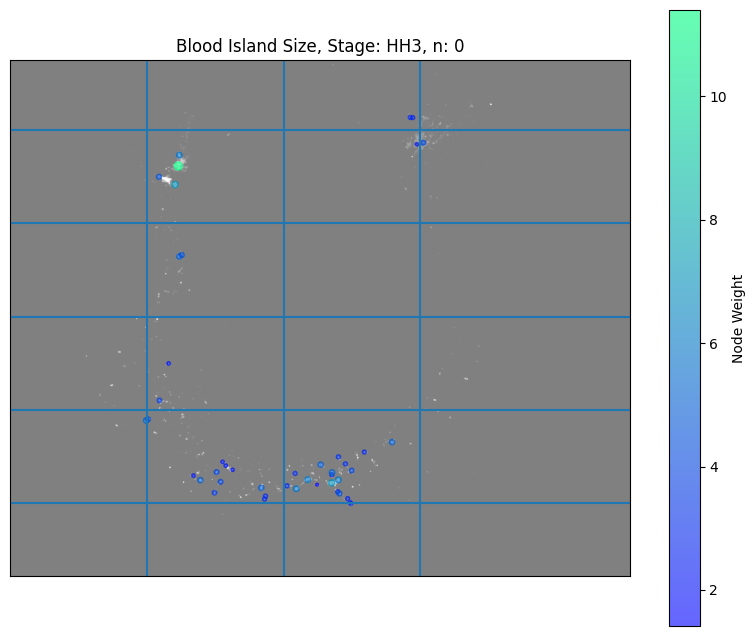

142.17991703499308


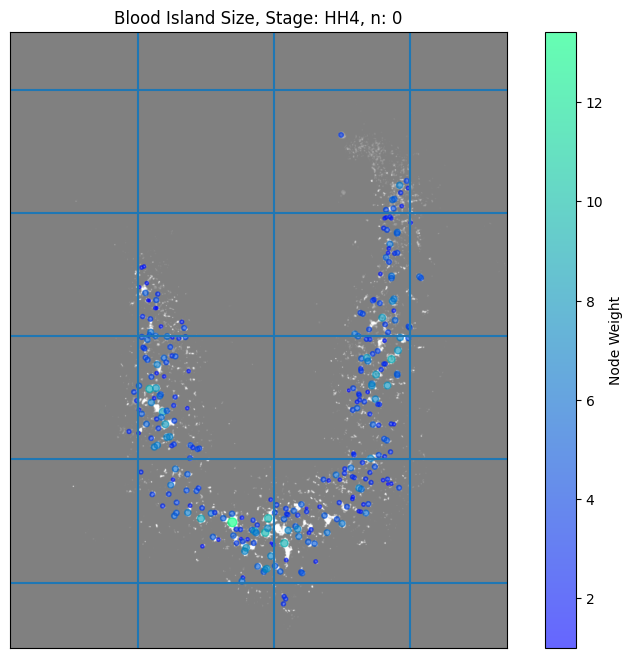

181.14528183792333


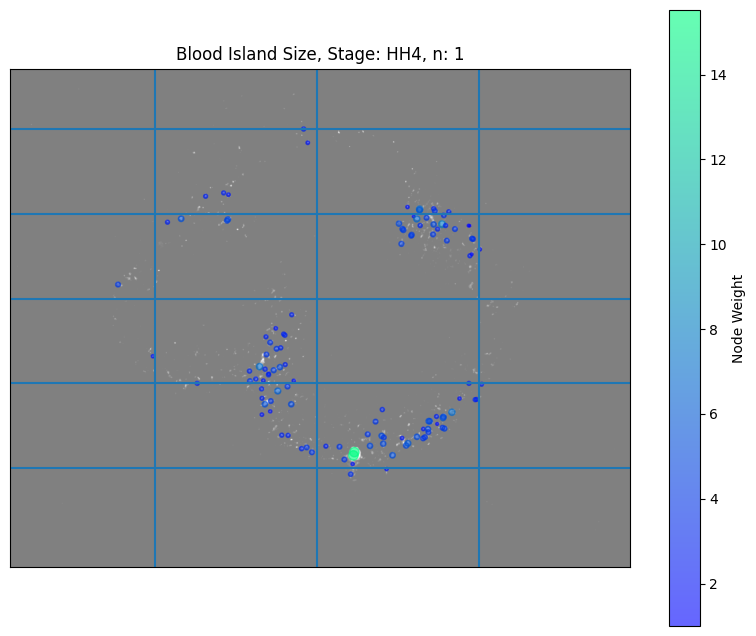

1008.5293713493367


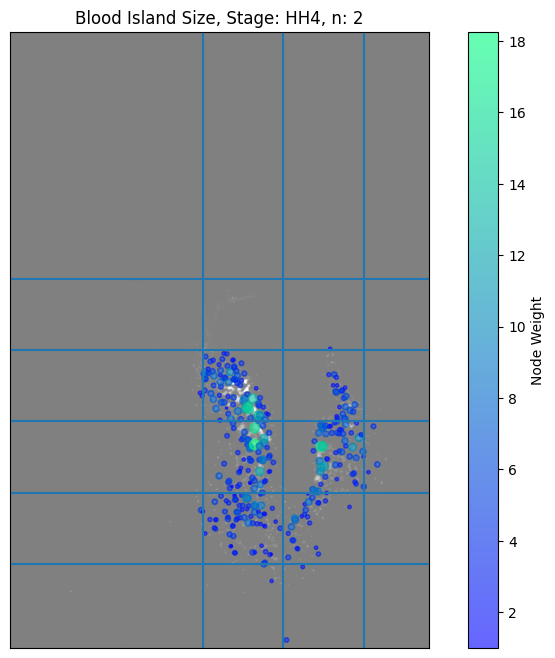

682.5495632761192


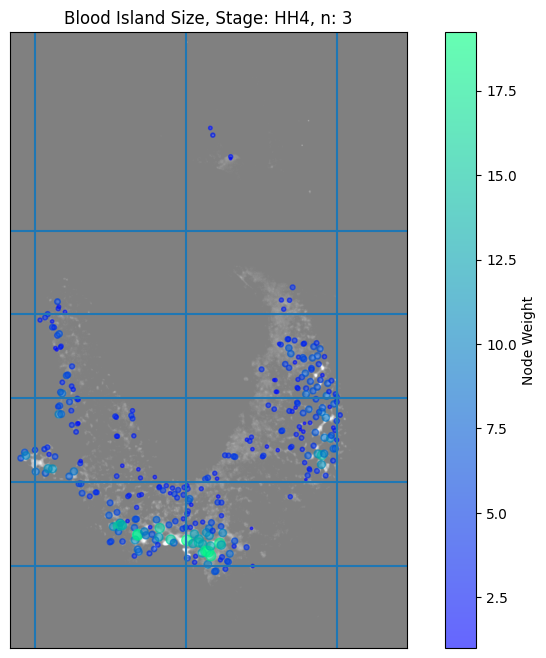

108.36228182195555


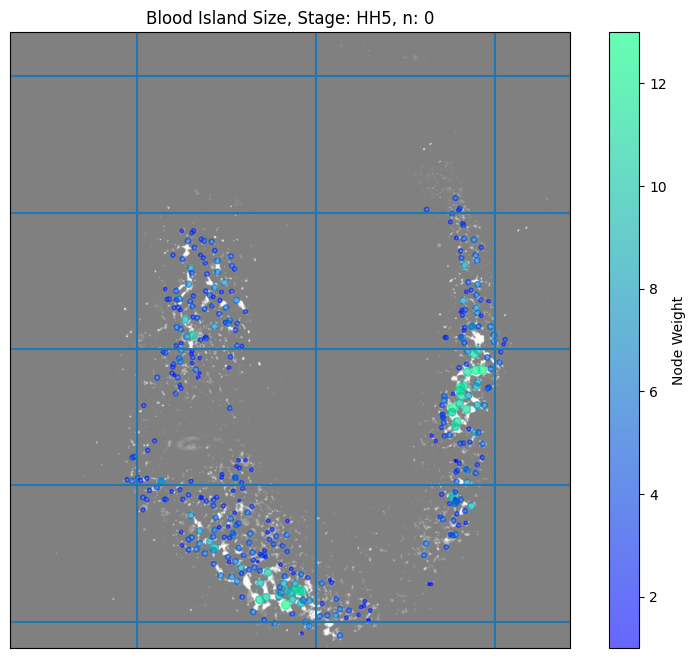

200.18733152422476


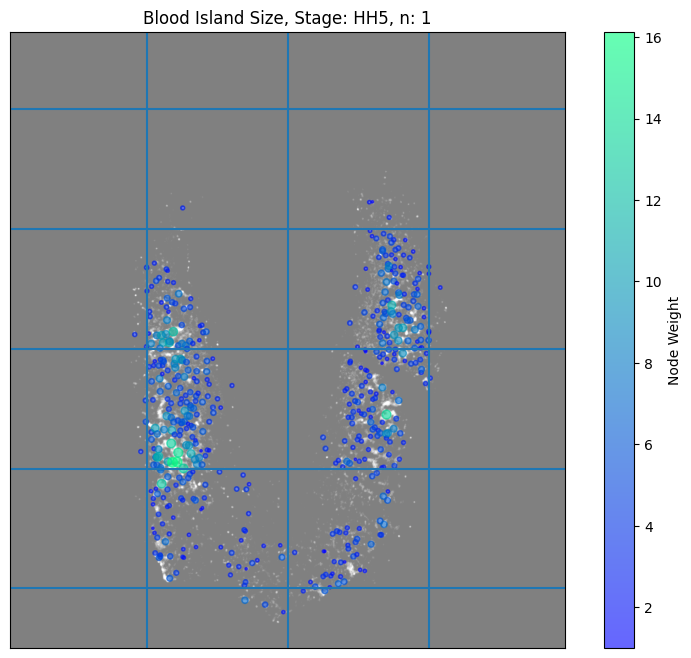

0.4474928496068742


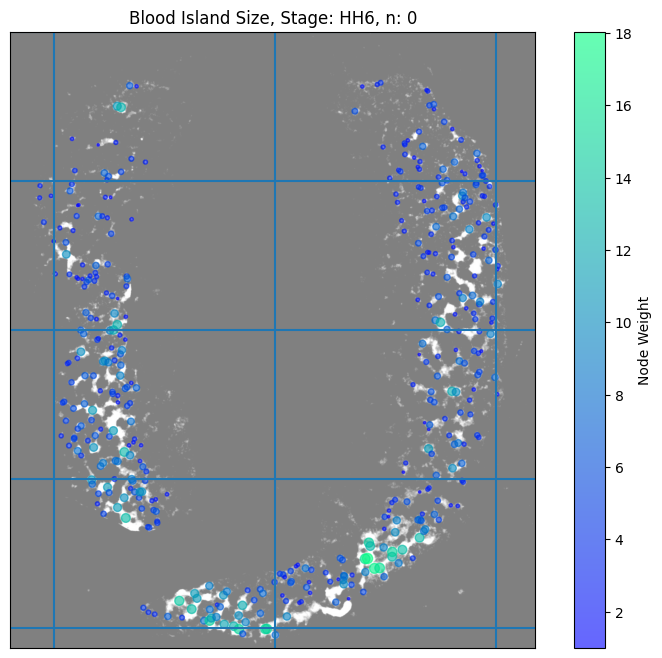

418.05469435703867


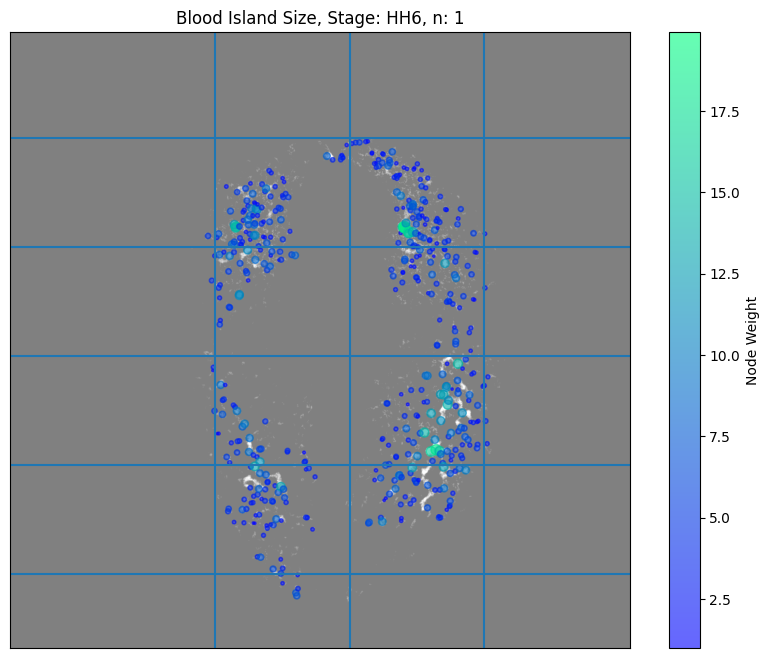

146.69365771123114


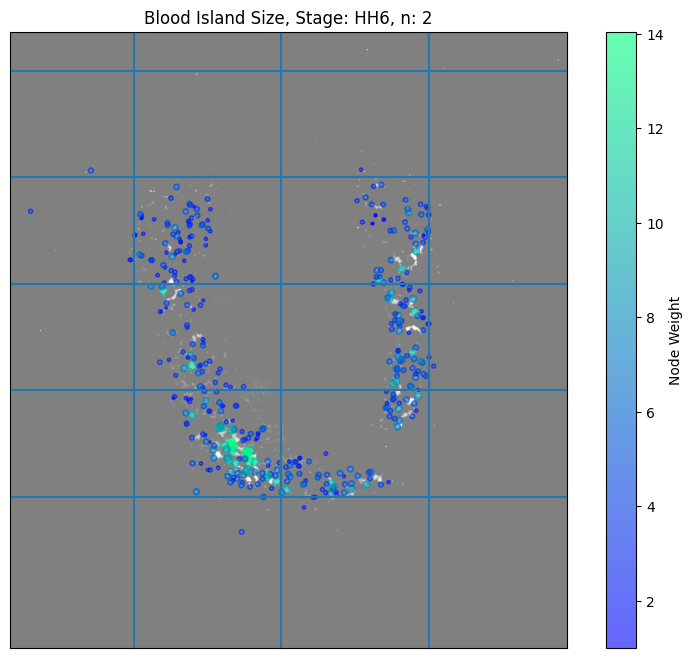

560.0606686197876


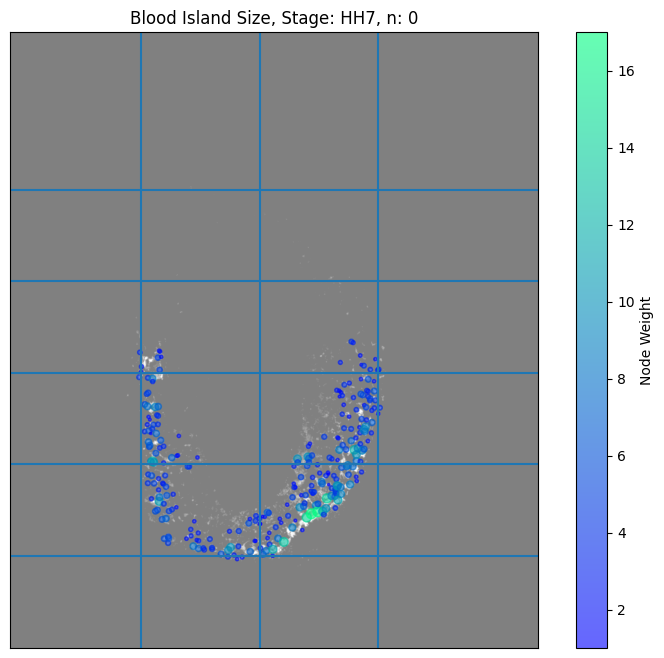

371.5844887838002


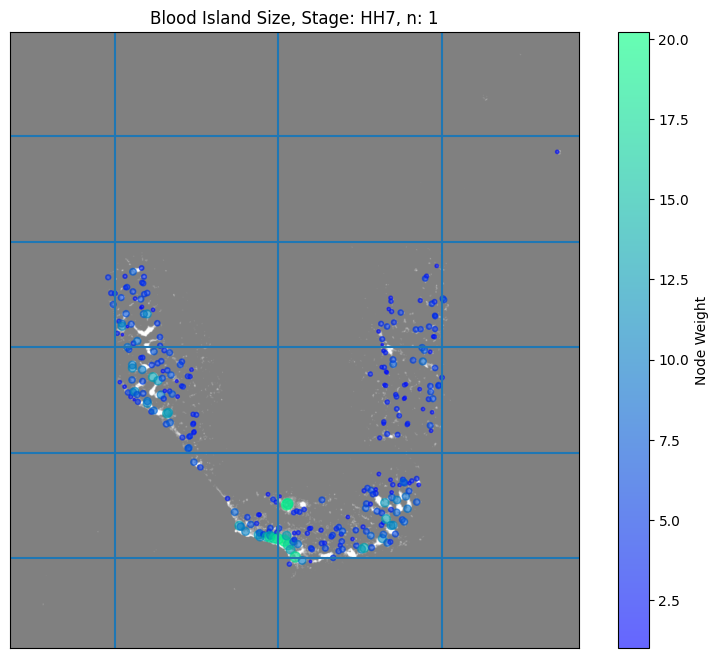

100.70842782553893


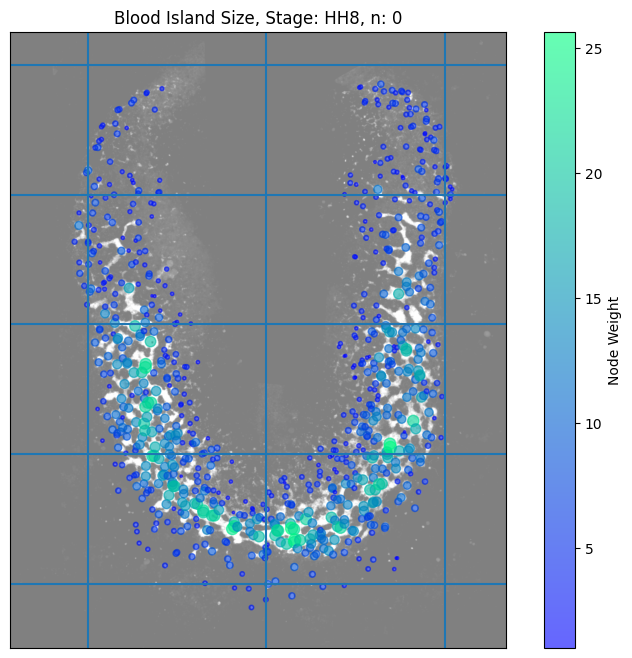

52.89286282622129


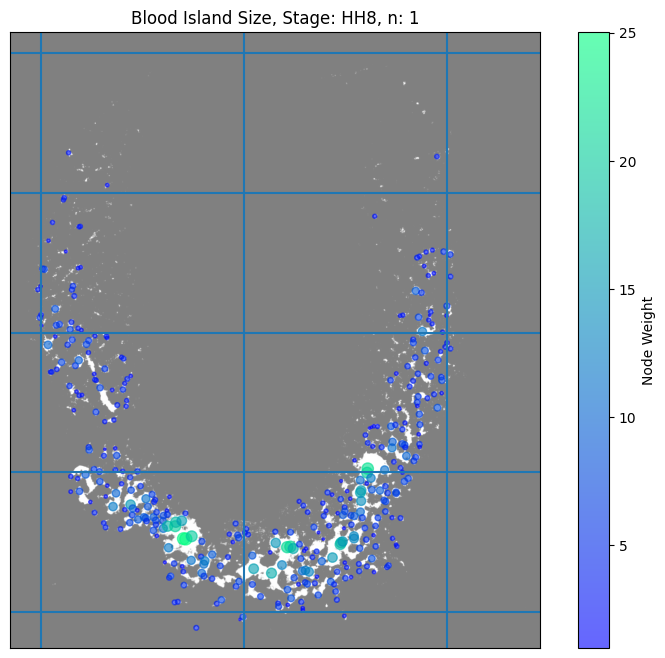

378.4496334276005


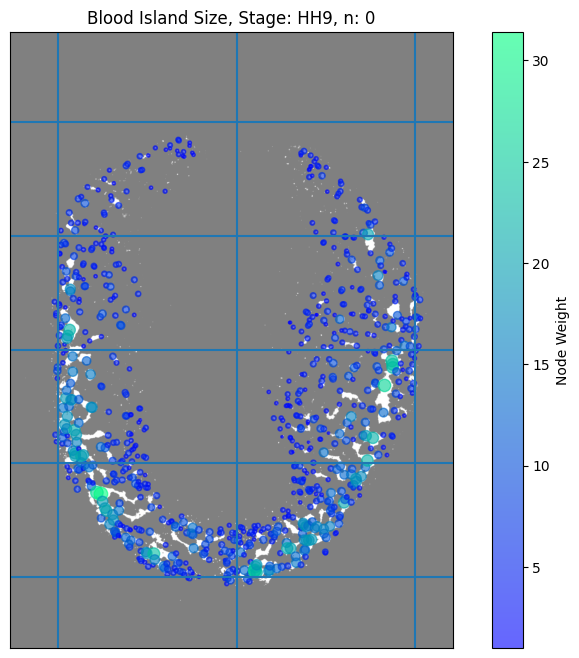

96.48058077580356


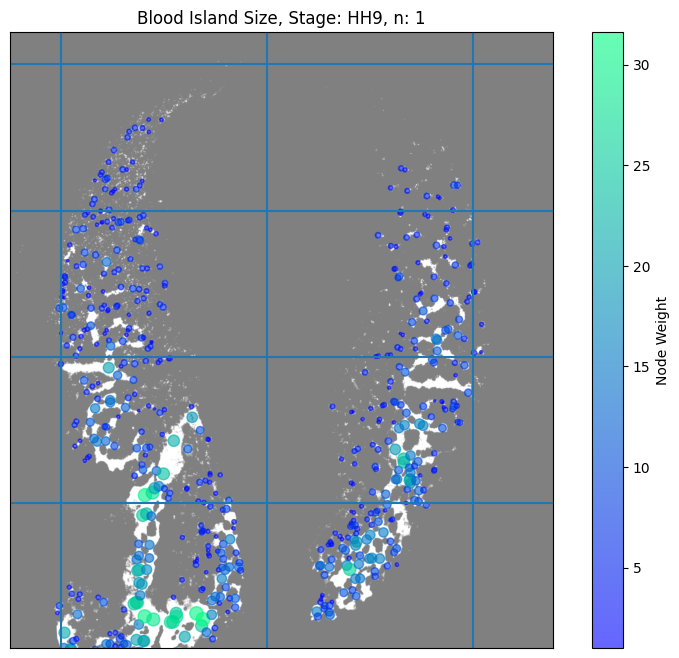

10.040184760416423


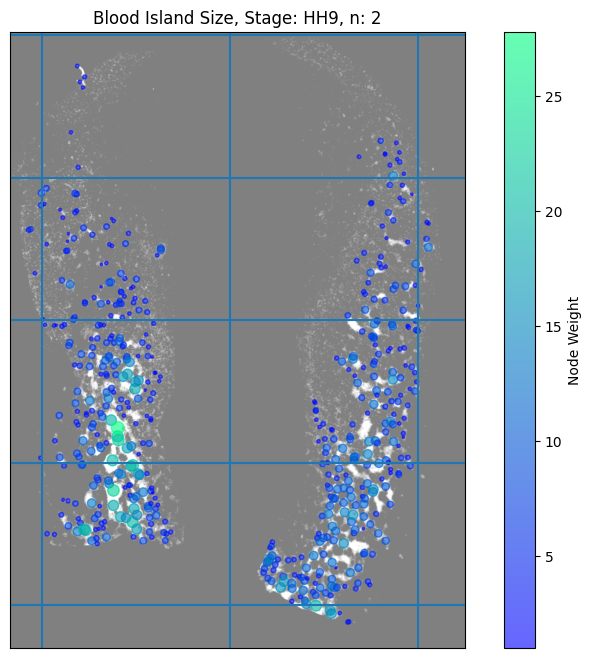

630.5379612889396


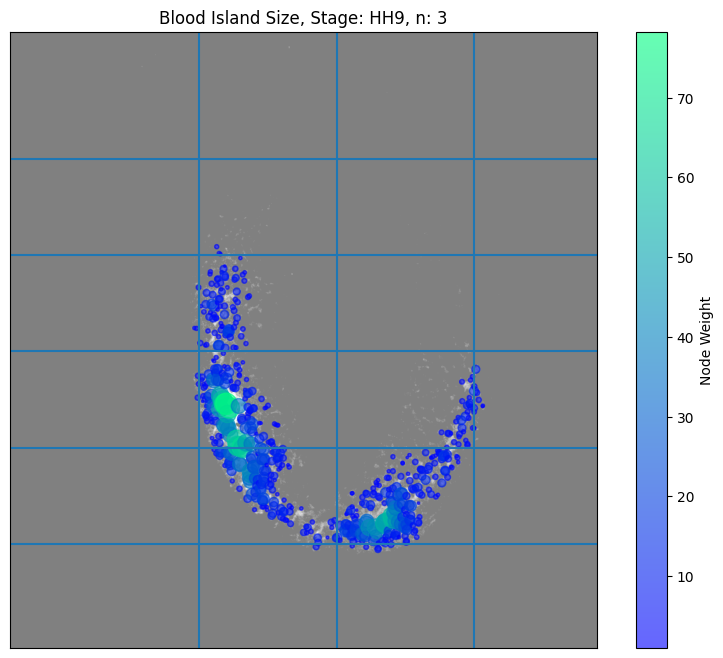

447.04296773421106


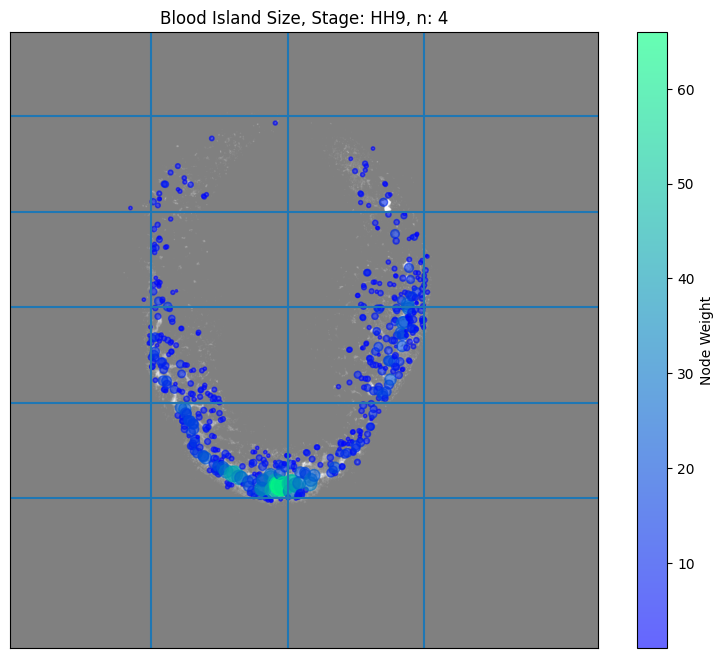

121.93118511673788


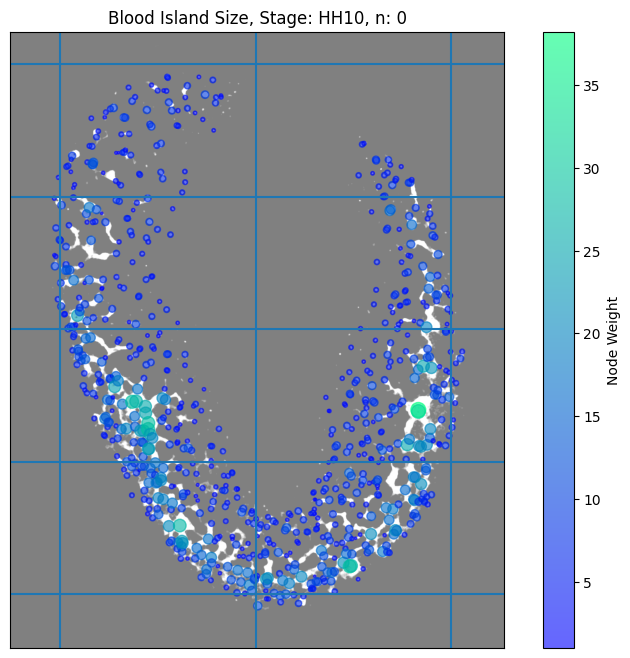

214.55974600241302


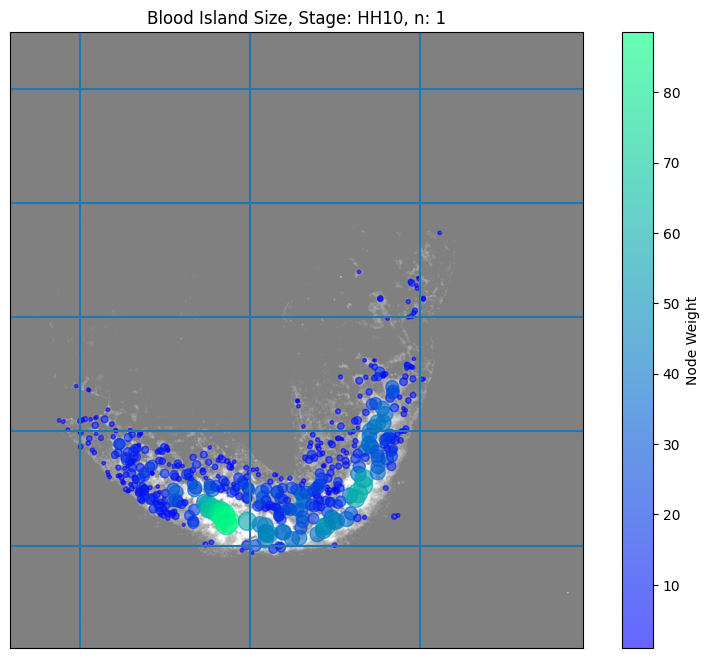

190.57867686928194


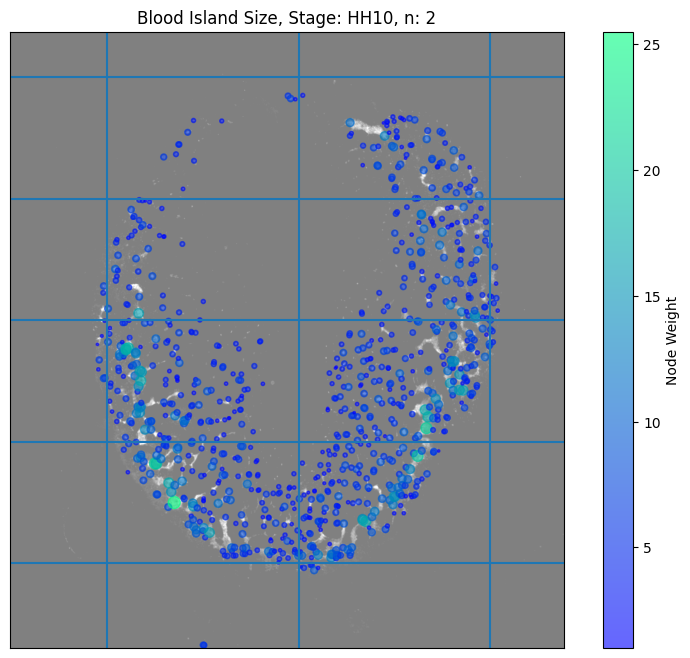

9.680339824929433


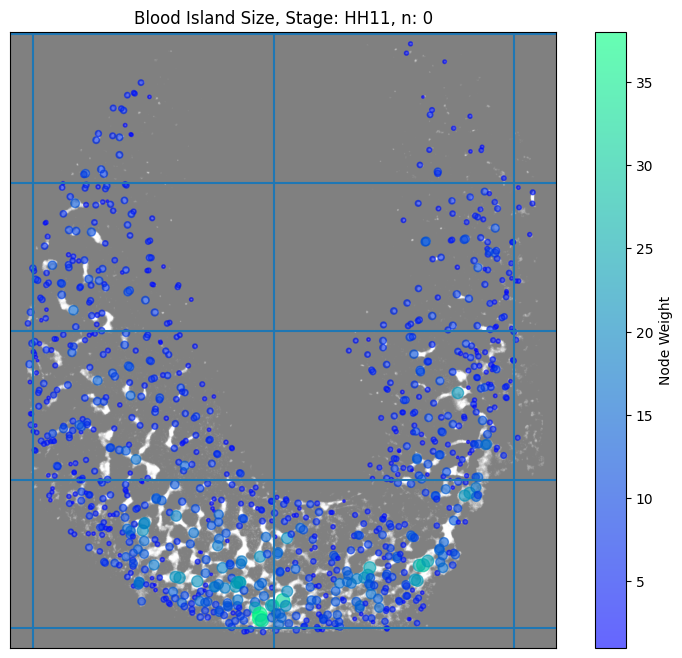

112.41599024732022


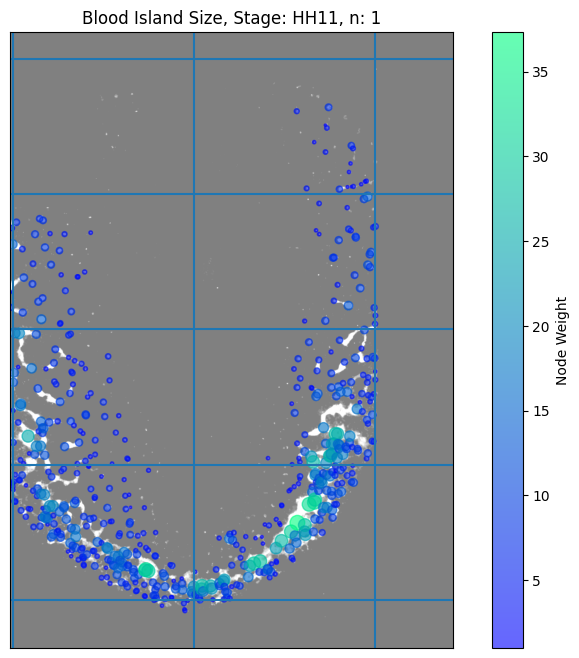

53.99856113890951


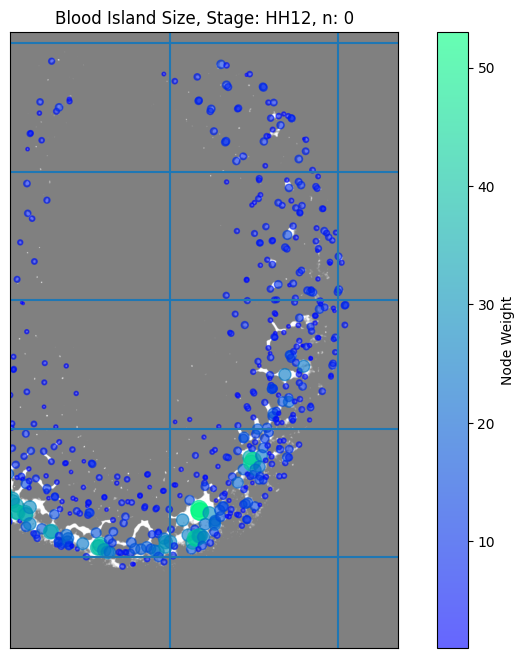

358.5277362256131


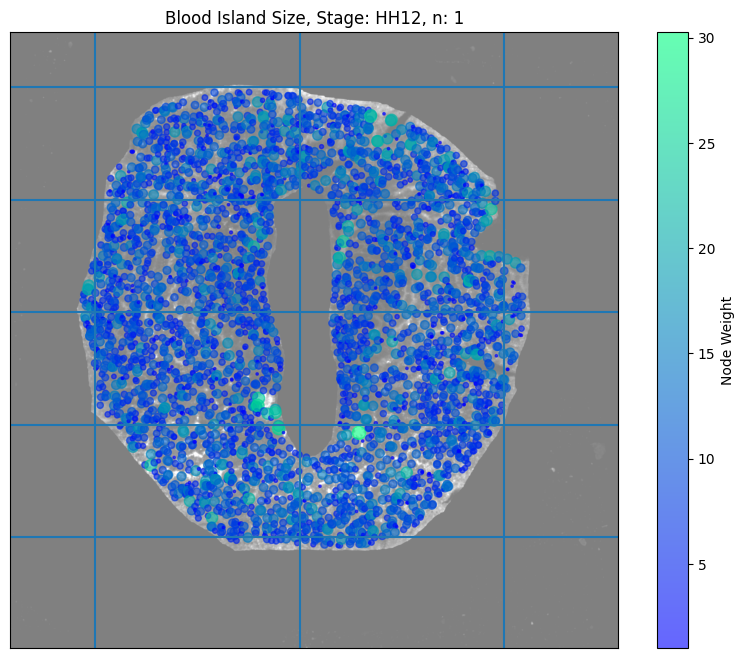

479.1976790118533


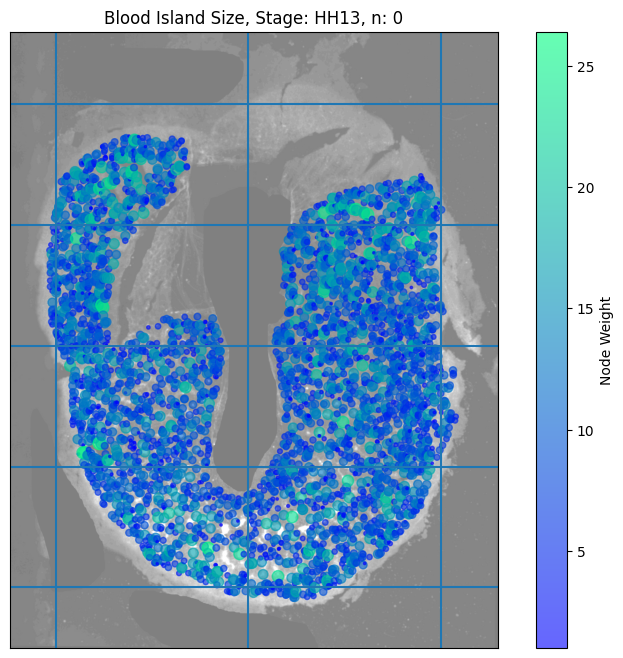

391.5285340525418


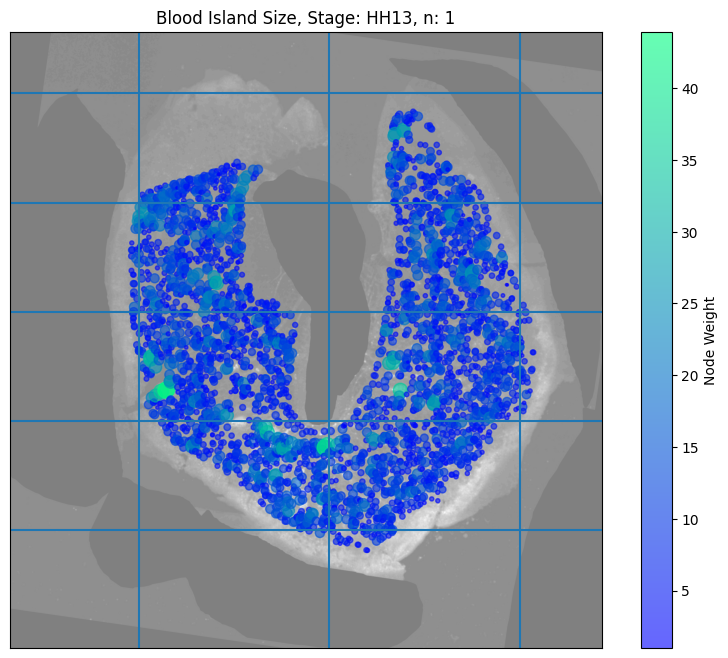

In [ ]:
nrows = 4
ncolumns = 2
nodes_data = pd.DataFrame(columns=["Stage","n","Row","Column","Number of Nodes","Nodes Degree"])
collected_data = []
rotated_images = []

#specify input image
for i in range(len(stages)):
    stage=stages[i]

    for n in range(len(nodes_all_stages[i])):
        if stage==3 and n==1:
            continue
        path = f"data/skeleton/all/"  
        image = cv2.imread(f'{path}n{n+1}_hh{stage}_plain_scaled.jpg')
        height = len(image)
        width = len(image[0])
        nodes = nodes_all_stages[i][n].copy()
        adj = adj_all_stages[i][n].copy()

        #display unrotated
        #fig, ax = plt.subplots(figsize=(10, 8))
        #ax.imshow(image, cmap=plt.cm.gray)
        #scatter = ax.scatter(nodes['x'], nodes['y'], c='red', s=3, alpha=0.6, label='Nodes')
        #plt.show()

        #append number of neighbours information
        nodes = calc_degrees(adj,nodes)
        #standardise the rotation eg. if embryo is diagonal
        nodes = rotate_all_nodes(nodes,stage,n+1)

        #rotate original image for display
        data = pd.read_csv("data/skeleton/rotation_log.csv")
        data_row = data[(data["Stage"]==stage) & (data["N"]==n+1)]
        theta = data_row["Angle"].iloc[0]
        if theta>90:
            theta = theta-180
        elif theta < -175: #should be -90 technically: just had 1 image that genuinely should flip but cant be bothered to change it in the source files
            theta = theta + 180
        M = cv2.getRotationMatrix2D((width / 2, height / 2), -theta, 1.0)
        rotated_image = cv2.warpAffine(image, M, (width, height))
        rotated_images.append({"Stage":stage, "n":n,"image":rotated_image})

        #split into grid regions
        xmin = nodes["x"].quantile(0.01)
        xmax = nodes["x"].quantile(0.99)
        #ymin = nodes["y"].quantile(0.01)
        ymax = nodes["y"].quantile(0.99)

        ymin_unrot = data_row["AnteriorY"].iloc[0]/4
        _,ymin = rotate_nodes(data_row["AnteriorX"].iloc[0]/4,ymin_unrot,theta,width,height)

        print(ymin)
        col_lines = np.linspace(xmin,xmax,ncolumns+1)
        row_lines = np.linspace(ymin,ymax,nrows+1)


        #if stage == 5 and n==0:
        if 1==1:
            fig, ax = plt.subplots(figsize=(10, 8))
            #plot grid lines
            ax.hlines(row_lines,0,width)
            ax.vlines(col_lines,0,height)

            #plot rtoated iamge
            ax.imshow(rotated_image, cmap=plt.cm.gray,alpha=0.5)

            #plot nodes
            #should be x4? pixel to micron ratio?
            scatter = ax.scatter(nodes['x'], nodes['y'], c=nodes['weight'], s=nodes['weight']*3, alpha=0.6, label='Nodes',cmap="winter")
            plt.colorbar(scatter, label="Node Weight")
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

            ax.set_xlim(0,width)
            ax.set_ylim(height,0)
            plt.title(f"Blood Island Size, Stage: HH{stage}, n: {n}")
            plt.show()

        for c in range(ncolumns):
            for r in range(nrows):
                # Ensure lower bound is strictly smaller than upper bound for .between()
                x_lower = min(col_lines[c], col_lines[c+1])
                x_upper = max(col_lines[c], col_lines[c+1])
                
                y_lower = min(row_lines[r], row_lines[r+1])
                y_upper = max(row_lines[r], row_lines[r+1])
                nodes_region = nodes[nodes["x"].between(x_lower,x_upper) & nodes["y"].between(y_lower,y_upper)]
                

                num_nodes = len(nodes_region)
                # Avoid 'NaN' or warnings if a grid region has absolutely zero nodes
                avg_degree = np.mean(nodes_region["degree"]) if num_nodes > 0 else 0

                avg_weight = np.mean(nodes_region["weight"]) if num_nodes > 0 else 0
                
                # 2. Append the data as a dictionary to your list
                collected_data.append({
                    "Stage": stage,
                    "n": n,
                    "Row": r,
                    "Column": c,
                    "Number of Nodes": num_nodes,
                    "Nodes Degree": avg_degree,
                    "Nodes Weight": avg_weight
                })

nodes_data=pd.DataFrame(collected_data)
rotated_images=pd.DataFrame(rotated_images)



   Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
0      3  0    0       0                6           1.0      6.374674
    Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
4       4  0    0       0               19      0.736842      2.930011
8       4  1    0       0                9      0.222222      3.441888
12      4  2    0       0               74      0.905405      5.513353
16      4  3    0       0               24      0.750000      4.128414
    Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
20      5  0    0       0               69      0.956522      4.076387
24      5  1    0       0               45      1.377778      5.160748
    Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
28      6  0    0       0               59      1.016949      4.631823
32      6  1    0       0              109      1.110092      5.201924
36      6  2    0       0               69      0.782609      3.274664
    Stag

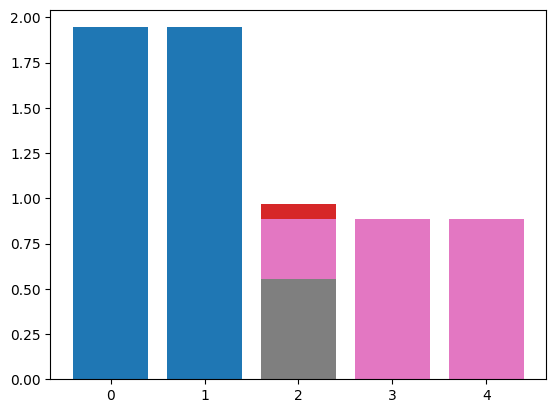

In [ ]:
for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    left_posterior = stage_data[ (stage_data["Row"]==0) & (stage_data["Column"]==0)]
    right_posterior = stage_data[ (stage_data["Row"]==0) & (stage_data["Column"]==1)]

    left_anterior = stage_data[ (stage_data["Row"]==1) & (stage_data["Column"]==0)]
    right_anterior = stage_data[ (stage_data["Row"]==1) & (stage_data["Column"]==1)]

    plt.bar(range(len(left_posterior)),left_posterior["Nodes Degree"].mean())
    print(left_posterior)

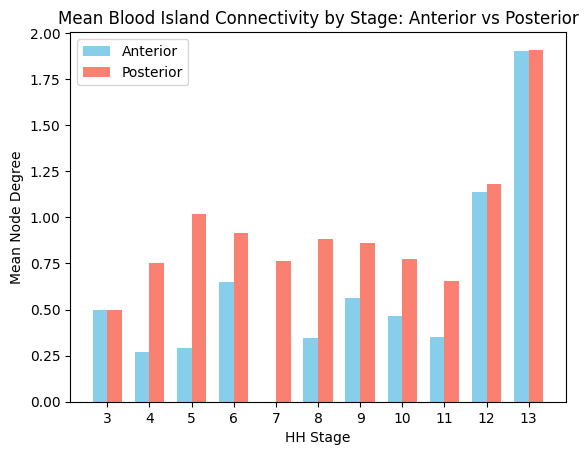

In [ ]:
#designed for n=2 rows only
mean_degree_anterior = []
mean_degree_posterior = []

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    posterior = stage_data[ (stage_data["Row"]==1)]

    anterior = stage_data[ (stage_data["Row"]==0)]

    mean_degree_anterior.append(anterior["Nodes Degree"].mean())
    mean_degree_posterior.append(posterior["Nodes Degree"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_degree_anterior, width, label='Anterior', color='skyblue')
plt.bar(x + width/2, mean_degree_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Node Degree')
plt.title('Mean Blood Island Connectivity by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

   Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
0      3  0    0       0                4      1.000000      7.193977
1      3  0    1       0                2      1.000000      4.736068
2      3  0    2       0                2      0.000000      2.920810
3      3  0    3       0               12      0.416667      3.398824
4      3  0    0       1                1      0.000000      2.000000
5      3  0    1       1                0      0.000000      0.000000
6      3  0    2       1                0      0.000000      0.000000
7      3  0    3       1               19      0.368421      4.006436
    Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
8       4  0    0       0                0      0.000000      0.000000
9       4  0    1       0               19      0.736842      2.930011
10      4  0    2       0               53      0.962264      4.464653
11      4  0    3       0               55      0.945455      4.746410
12      4  0   

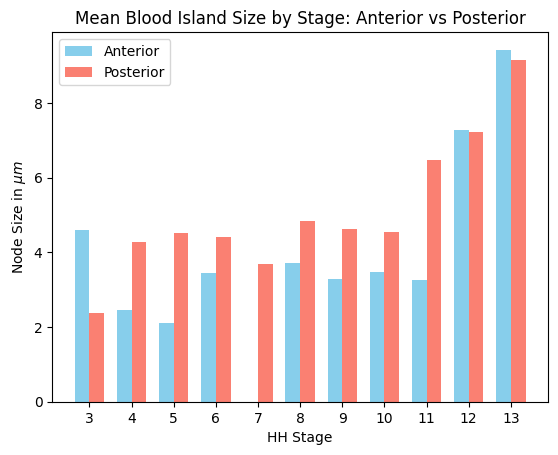

In [ ]:
#designed for n=2 rows only
mean_weight_anterior = []
mean_weight_posterior = []


for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]
    print(stage_data)

    posterior = stage_data[ (stage_data["Row"]==1)]

    anterior = stage_data[ (stage_data["Row"]==0)]
    mean_weight_anterior.append(anterior["Nodes Weight"].mean())
    mean_weight_posterior.append(posterior["Nodes Weight"].mean())

x = np.arange(len(stages))
width = 0.35  
# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x-width/2, mean_weight_anterior, width, label='Anterior', color='skyblue')
plt.bar(x+width/2, mean_weight_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Node Size in $\mu m$')
plt.title('Mean Blood Island Size by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

[[-0.175       0.825       1.825       2.825       3.825       4.825
   5.825       6.825       7.825       8.825       9.825     ]
 [-0.05833333  0.94166667  1.94166667  2.94166667  3.94166667  4.94166667
   5.94166667  6.94166667  7.94166667  8.94166667  9.94166667]
 [ 0.05833333  1.05833333  2.05833333  3.05833333  4.05833333  5.05833333
   6.05833333  7.05833333  8.05833333  9.05833333 10.05833333]
 [ 0.175       1.175       2.175       3.175       4.175       5.175
   6.175       7.175       8.175       9.175      10.175     ]]


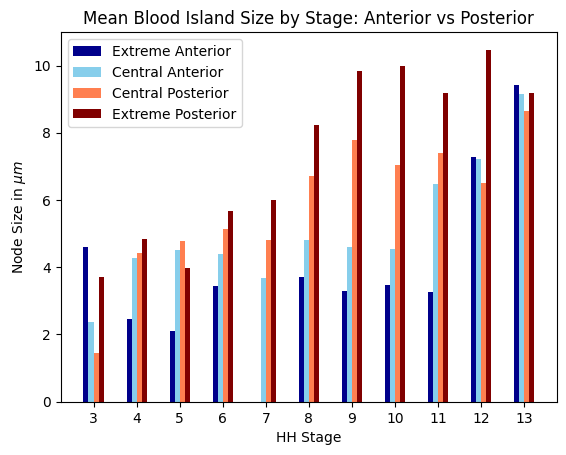

In [ ]:
#designed for n>2 rows
col_labels = ["Left", "Right"]
row_labels = ["Extreme Anterior", "Central Anterior","Central Posterior", "Extreme Posterior"]
mean_weights = pd.DataFrame(columns=row_labels,index=stages)

for i in stages:
    all_row_data = []
    for j in range(nrows):
        stage_data = nodes_data[nodes_data["Stage"]==i]

        current_row = stage_data[ (stage_data["Row"]==j)]

        mean_weight_current = current_row["Nodes Weight"].mean()

        label = row_labels[j]

        mean_weights.loc[i,label] = mean_weight_current
        #mean_weight_posterior.append(posterior["Nodes Weight"].mean())

x = np.arange(len(stages))
width = 0.35 
positions = np.linspace(x-width/2,x+width/2,nrows) 
print(positions)
colours = ["darkblue","skyblue","coral","maroon"]
for j in range(nrows):
    label = row_labels[j]
    plt.bar(positions[j], mean_weights[label], width/(nrows-1), label=label, color=colours[j])


# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
#plt.bar(x-width/2, mean_weight_anterior, width, label='Anterior', color='skyblue')
#plt.bar(x+width/2, mean_weight_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Node Size in $\mu m$')
plt.title('Mean Blood Island Size by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

     Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
104     13  0    0       0              663      1.987934      9.270163
105     13  0    1       0              865      1.788439      8.791305
106     13  0    0       1              818      1.965770      9.379839
107     13  0    1       1             1166      1.811321      8.606713
108     13  1    0       0              518      1.901544      9.463785
109     13  1    1       0              884      1.813348      9.450355
110     13  1    0       1              516      1.786822      8.938293
111     13  1    1       1              879      1.739477      8.607993


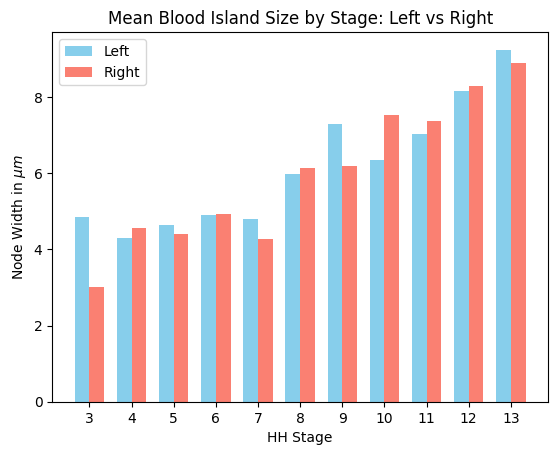

In [11]:
mean_weight_left= []
mean_weight_right = []
print(stage_data)

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    posterior = stage_data[ (stage_data["Column"]==1)]

    anterior = stage_data[ (stage_data["Column"]==0)]
    mean_weight_left.append(anterior["Nodes Weight"].mean())
    mean_weight_right.append(posterior["Nodes Weight"].mean())

x = np.arange(len(stages))
width = 0.35  
# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x-width/2, mean_weight_left, width, label='Left', color='skyblue')
plt.bar(x+width/2, mean_weight_right, width, label='Right', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Node Width in $\mu m$')
plt.title('Mean Blood Island Size by Stage: Left vs Right')
plt.xticks(x, stages)
plt.legend()

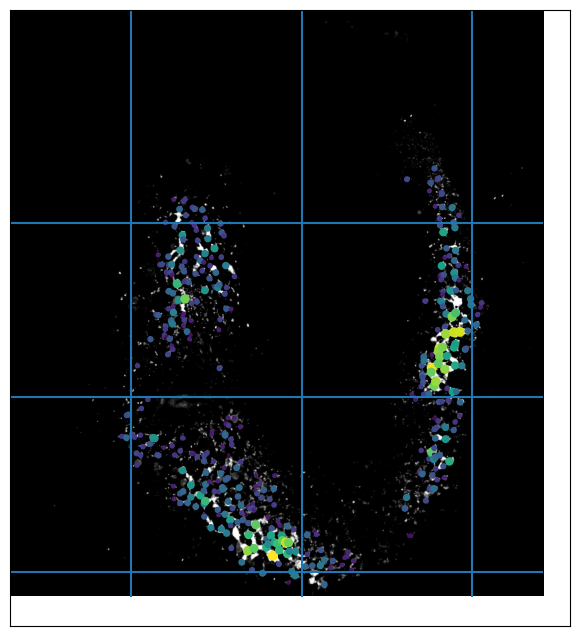

In [33]:
stage = 5
stage_id = stages.index(stage)
n=0
nodes = nodes_all_stages[stage_id][n].copy()
adj = adj_all_stages[stage_id][n].copy()

#append number of neighbours information
nodes = calc_degrees(adj,nodes)
#standardise the rotation eg. if embryo is diagonal
nodes = rotate_all_nodes(nodes,stage,n+1)



#plot rtoated iamge
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.logical_and(rotated_images["Stage"]==stage, rotated_images["n"]==n)
image = rotated_images[mask]["image"].iloc[0]

height = len(image)
width = len(image[0])
ax.imshow(image, cmap=plt.cm.gray)

xmin = nodes["x"].quantile(0.01)
xmax = nodes["x"].quantile(0.99)
#ymin = nodes["y"].quantile(0.01)
ymax = nodes["y"].quantile(0.99)

ymin_unrot = data_row["AnteriorY"].iloc[0]/4
_,ymin = rotate_nodes(data_row["AnteriorX"].iloc[0]/4,ymin_unrot,theta,width,height)

col_lines = np.linspace(xmin,xmax,ncolumns+1)
row_lines = np.linspace(ymin,ymax,nrows+1)



#plot grid lines
ax.hlines(row_lines,0,width)
ax.vlines(col_lines,0,height)


#plot nodes
scatter = ax.scatter(nodes['x'], nodes['y'], c=nodes['weight'], s=nodes["weight"]*3, alpha=1, label='Nodes')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()

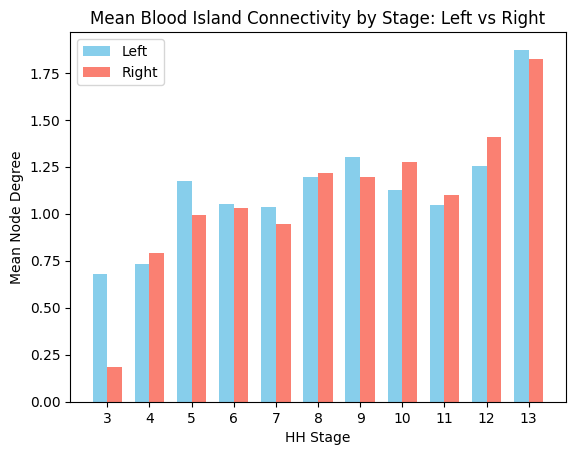

In [9]:
mean_degree_left = []
mean_degree_right = []

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    right = stage_data[ (stage_data["Column"]==1)]

    left = stage_data[ (stage_data["Column"]==0)]

    mean_degree_left.append(left["Nodes Degree"].mean())
    mean_degree_right.append(right["Nodes Degree"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_degree_left, width, label='Left', color='skyblue')
plt.bar(x + width/2, mean_degree_right, width, label='Right', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Node Degree')
plt.title('Mean Blood Island Connectivity by Stage: Left vs Right')
plt.xticks(x, stages)
plt.legend()

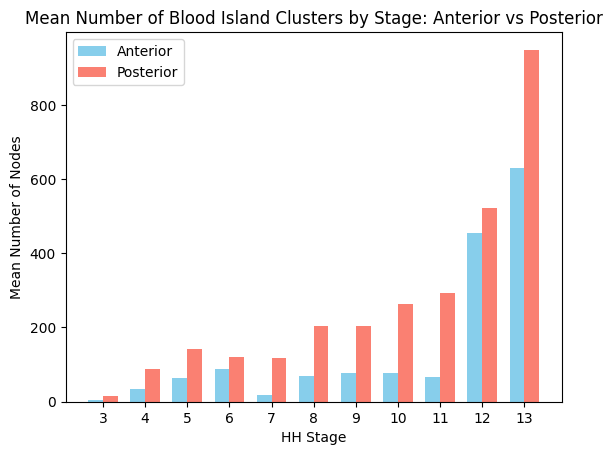

In [10]:
mean_num_anterior = []
mean_num_posterior = []
for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    posterior = stage_data[ (stage_data["Row"]==1)]

    anterior = stage_data[ (stage_data["Row"]==0)]

    mean_num_anterior.append(anterior["Number of Nodes"].mean())
    mean_num_posterior.append(posterior["Number of Nodes"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_num_anterior, width, label='Anterior', color='skyblue')
plt.bar(x + width/2, mean_num_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Number of Nodes')
plt.title('Mean Number of Blood Island Clusters by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

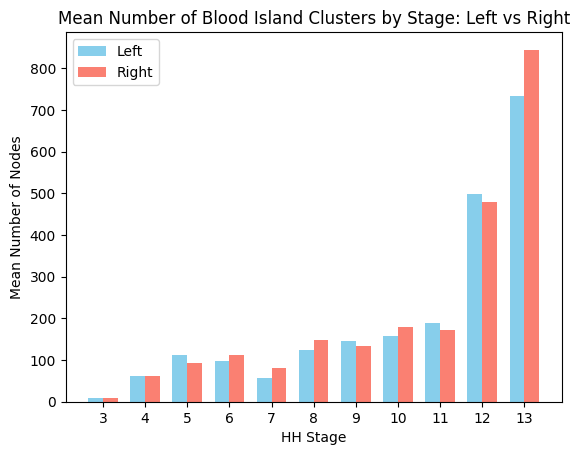

In [11]:
mean_degree_left = []
mean_degree_right = []

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    right = stage_data[ (stage_data["Column"]==1)]

    left = stage_data[ (stage_data["Column"]==0)]

    mean_degree_left.append(left["Number of Nodes"].mean())
    mean_degree_right.append(right["Number of Nodes"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_degree_left, width, label='Left', color='skyblue')
plt.bar(x + width/2, mean_degree_right, width, label='Right', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Number of Nodes')
plt.title('Mean Number of Blood Island Clusters by Stage: Left vs Right')
plt.xticks(x, stages)
plt.legend()

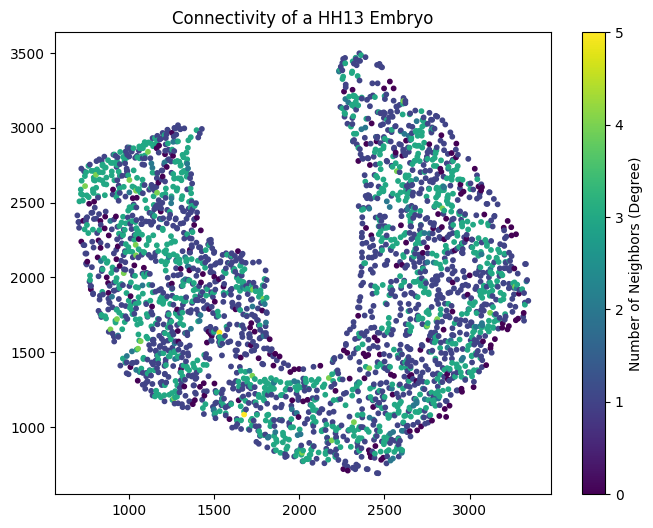

In [12]:
#specify input image
stage=13
stage_id = stages.index(stage)
n=2

path = f"data/skeleton/all/"  
image = tiff.imread(f'{path}n{n}_hh{stage}_skeleton.tif')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_degrees(adj,nodes)


plt.figure(figsize=(8, 6))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], height-nodes['y'], c=nodes['degree'], cmap='viridis', s=10)
plt.colorbar(scatter, label='Number of Neighbors (Degree)')
plt.title(f'Connectivity of a HH{stage} Embryo')
plt.show()

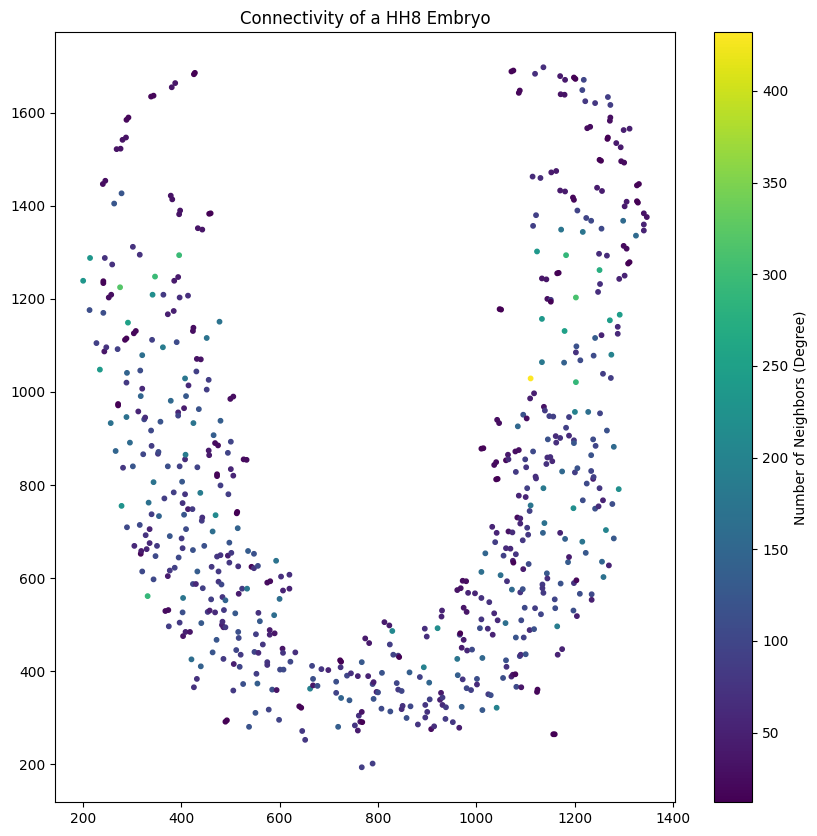

In [17]:
#specify input image
stages = [3,4,5,6,7,8,9,10,11,12,13]
stage=8
stage_id = stages.index(stage)
n=1

path = f"data/skeleton/all/"  
image = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
height = len(image)
width = len(image[0])
nodes = nodes_all_stages[stage_id][n-1]
adj = adj_all_stages[stage_id][n-1]

#append the degree data
nodes = calc_dists(adj,nodes)




fig,ax=plt.subplots(figsize=(10,10))
# c='degree' maps the color to the feature, cmap is the color scheme
scatter = plt.scatter(nodes['x'], height-nodes['y'], c=nodes['distances'], cmap='viridis', s=10)
fig.colorbar(scatter, label='Number of Neighbors (Degree)')
#ax.imshow(image, cmap=plt.cm.gray)
ax.set_title(f'Connectivity of a HH{stage} Embryo')

plt.show()